![](twisting.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.masterclass as master
from skrom.utils.visualization.color_palette import set_color_palette

problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R
import sci_mplstyle_package

PETSc available: True


### Plot Properties


In [3]:
import sci_mplstyle_package
set_color_palette();

In [4]:
generate_data = True
visualize = True
run_svd = True
_hyperreduce_ecsw = True
run_rom = True
run_hyperrom = True
rom_report = True

## Full Order Simulation


In [5]:
# Suppress logs during parallel execution
import logging

# Global off switch
logging.disable(logging.CRITICAL)

# Also remove existing handlers that may already be attached in Jupyter
root = logging.getLogger()
for h in root.handlers[:]:
    root.removeHandler(h)
root.addHandler(logging.NullHandler())
root.setLevel(logging.CRITICAL)

In [6]:
# Conditional execution block for simulation data generation
if generate_data:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots = 32)
    sim.run_simulation()


Snap 1/64 params=[0.98921171 1.01706001]
1 9.783966559661602
2 0.9489547867710364
3 1.4359713891213448
4 0.41443562710071946
5 0.6309887815956123
6 0.0639302928263871
7 0.024990313978985913
8 9.249347283574386e-05
Snap 2/64 params=[0.73740472 1.8719303 ]
1 0.015586221248811472
2 0.00013206742838328428
Snap 3/64 params=[0.51799218 1.48391112]
1 0.0023647510665698425
2 2.1828595180428287e-06
Snap 4/64 params=[0.77101653 1.62709427]
1 0.005835809543350414
2 1.1167419897293122e-05
Snap 5/64 params=[0.84856188 1.27550396]
1 0.005985267203549282
2 1.190115943105052e-05
Snap 6/64 params=[0.59669767 1.61693884]
1 0.010769119732844067
2 5.5781290099101384e-05
Snap 7/64 params=[0.62738807 1.22352597]
1 0.006180391089583243
2 1.2476353357546472e-05
Snap 8/64 params=[0.88047728 1.88403553]
1 0.0016985784679266565
2 1.1286745109454808e-06
Snap 9/64 params=[0.92996953 1.37729336]
1 0.006488961150043902
2 1.3835224334170857e-05
Snap 10/64 params=[0.68713471 1.73435338]
1 0.009637876162663072
2 4.3637

### Load Simulation Data

In [7]:
# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_1_h\ROM_data


### Generate Training Solution Dataset



In [8]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = rom_data.param_list

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

64


### Mean Subtraction

In [9]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

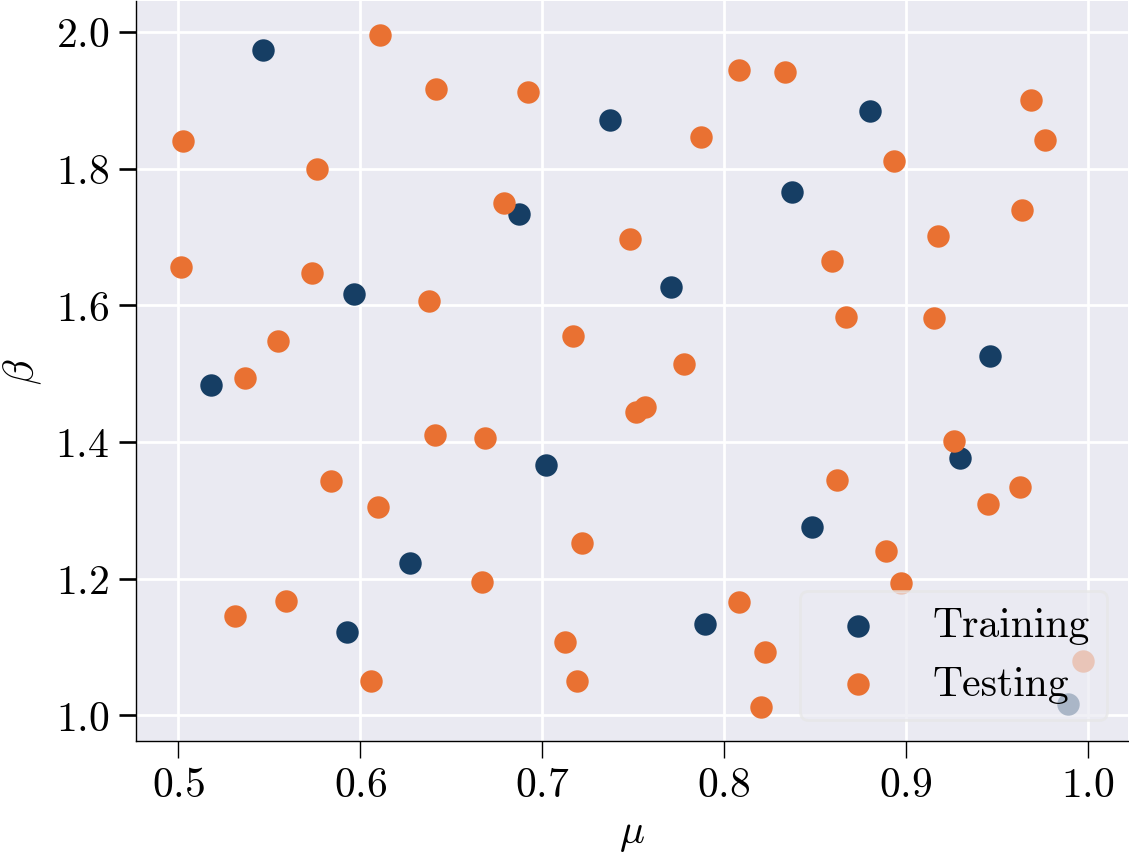

In [10]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 8


Text(0.5, 0, 'POD modes ($k$)')

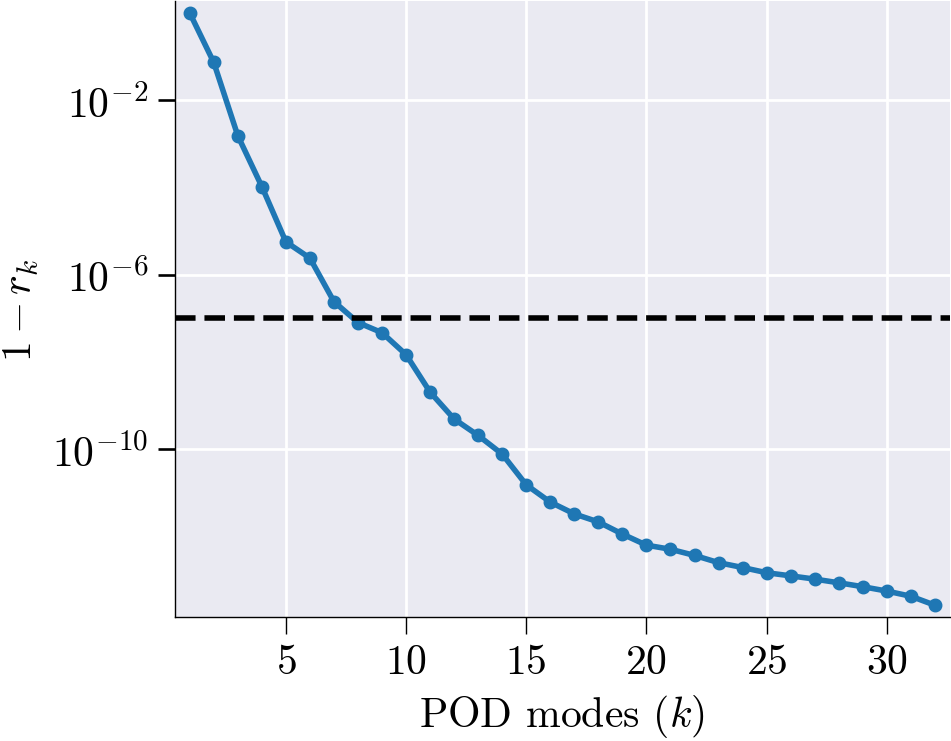

In [11]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-7,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors

n_sel = 6

# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation


In [12]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    #   n_sel : number of basis vectors (modes) to retain in the ROM
    rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel, train_ref=NLS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_1_h\ROM_data


In [13]:
if run_rom:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/32 params=[0.66680271 1.19531645]
1 0.002177178618792688
2 1.3313913894542494e-06
Snap 2/32 params=[0.89375125 1.81159795]
1 0.0022113688403747394
2 1.92750017117983e-06
Snap 3/32 params=[0.86193867 1.34387451]
1 0.004629603830916729
2 7.752591591906112e-06
Snap 4/32 params=[0.57360027 1.64765219]
1 0.011293197369857138
2 5.530964197848796e-05
Snap 5/32 params=[0.53645428 1.49369881]
1 0.0006154490582987149
Snap 6/32 params=[0.77799067 1.51427722]
1 0.006745995986417183
2 1.5192261900501016e-05
Snap 7/32 params=[0.99729198 1.07976347]
1 0.009779448136302459
2 3.243435792595105e-05
Snap 8/32 params=[0.69216846 1.91283806]
1 0.01644004614541514
2 0.000130741561478057
Snap 9/32 params=[0.7216945  1.25213704]
1 0.008633363211451412
2 2.4589478859531307e-05
Snap 10/32 params=[0.96386031 1.73939024]
1 0.0006946138625780608
Snap 11/32 params=[0.80803574 1.16608281]
1 0.0038482686191545455
2 5.467713940422652e-06
Snap 12/32 params=[0.50250405 1.8408322 ]
1 0.01756080110729286
2 0.000140

In [14]:
if rom_report:
    #Assign values for the statistics
    NLS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up
    ROM_relative_error = rom.rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 9.9087e-09
Relative L2 Error:        5.6858e-09
L∞ Error:                 1.0577e-08
Relative L∞ Error:        1.9847e-08
RMSE:                     7.5526e-10
MAE:                      1.5138e-10

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             6.9389e-17
95th Percentile Error:    3.9987e-10

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 5.1432e-11
Max Rel L2 Error over time/parameter: 9.8497e-10
Min Rel L2 Error over time/parameter: 1.5731e-12
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

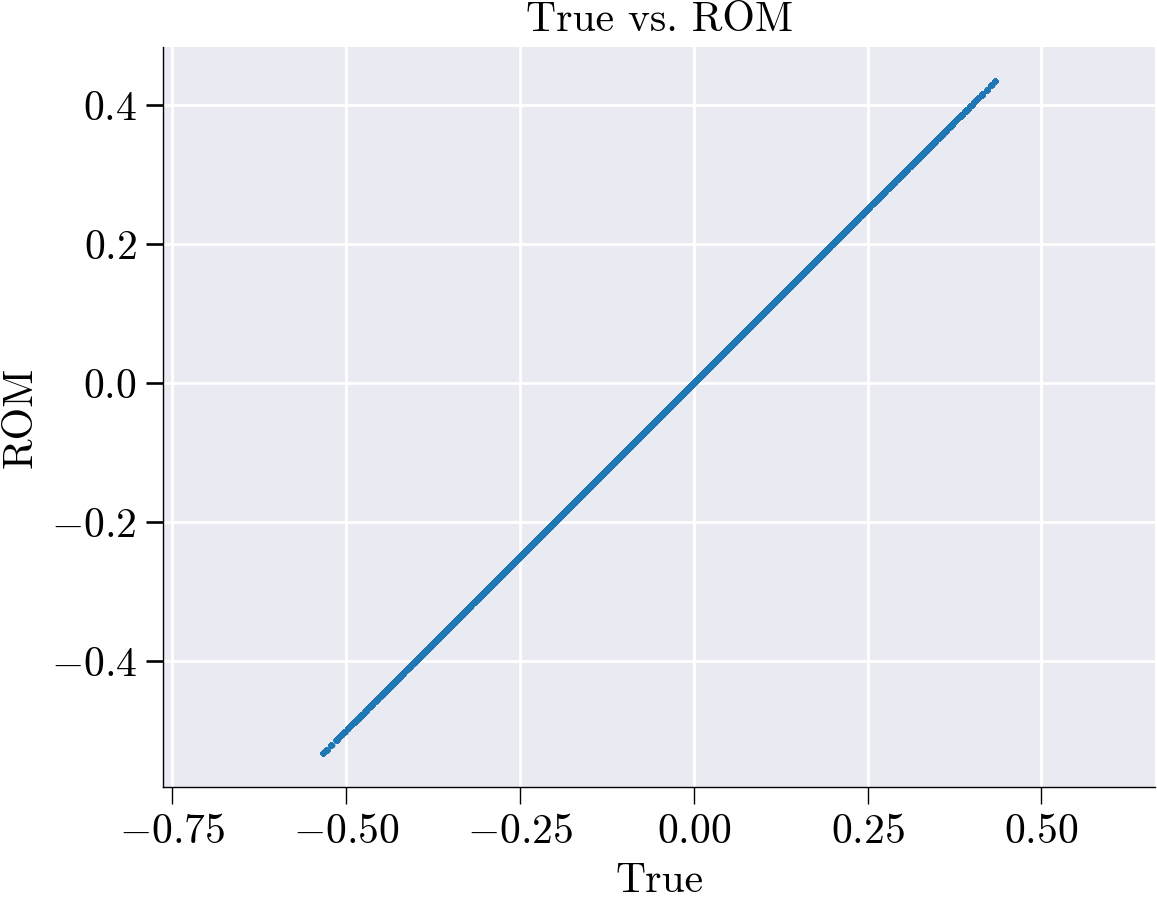

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


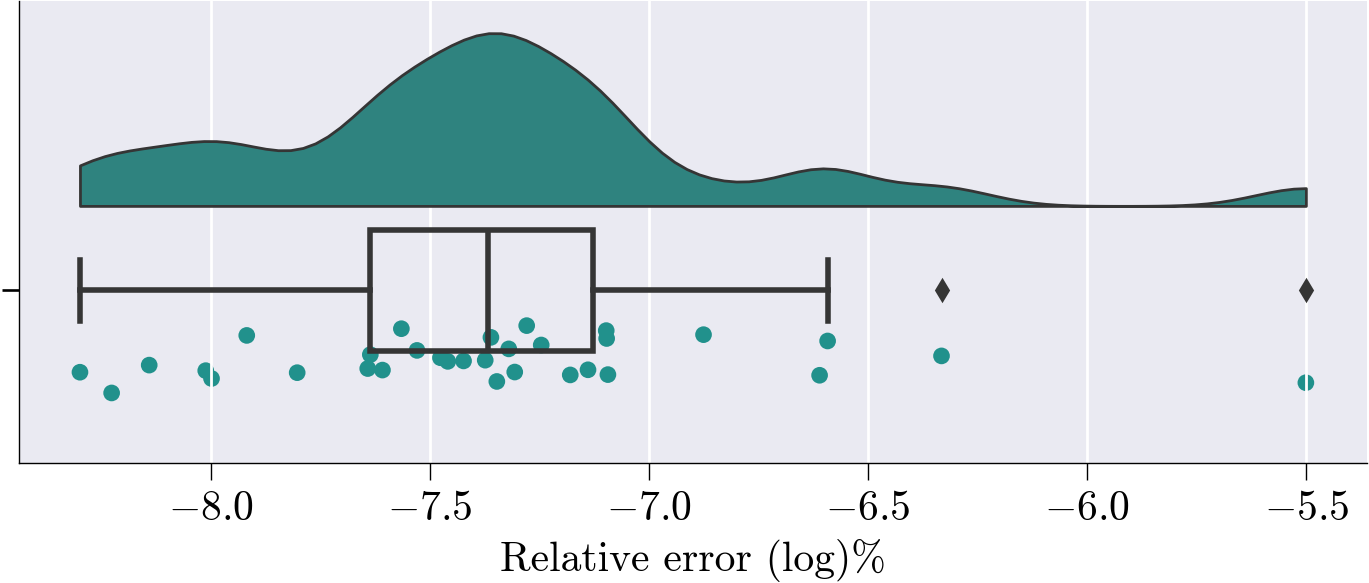

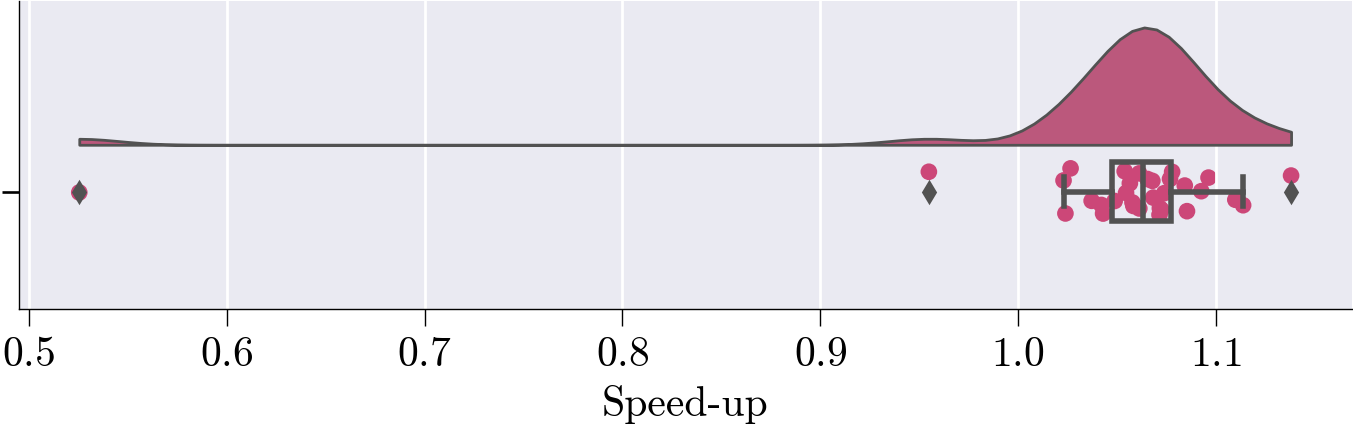

In [15]:
if rom_report:
    # --- ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        NLS_test,                   # full-order (true) solution snapshots
        NLS_rom,              # hyper-ROM-generated solution snapshots
        ROM_relative_error,   # precomputed relative error of the hyper-ROM
        ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )

## Hyper ROM Simulation


### Mesh Sampling


In [16]:
if _hyperreduce_ecsw:
    prob = ProblemNonLinear()
    dirichlet_dofs = prob.domain()['dirichlet_dofs']
    free_dofs = rom_data.basis.complement_dofs(dirichlet_dofs)
    prob.mesh = rom_data.mesh

In [17]:
if _hyperreduce_ecsw:
    # Create the ROM residual linear form object
    # This represents the linear form R(u,v) in the weak formulation of the PDE
    Residual = LinearFormROM(R,                    # Linear form function from problem definition
                            rom_data.basis,                 # Finite element basis functions
                            V_sel,                 # Selected POD modes (reduced basis)
                            free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

    # Extract parameter values corresponding to training snapshots
    # Uses the boolean mask to get only the parameter combinations used for training
    training_params = param_list[train_mask]

In [18]:
if _hyperreduce_ecsw:

    # Collect residual evaluations for all training snapshots
    # This creates the dataset needed for hyperreduction of nonlinear ROM terms
    q_mus = collect_residuals(
        NLS_train_ms,         # Mean-centered training snapshots
        NLS_train_mean,       # Mean temperature field
        V_sel,                # Selected POD basis modes
        reconstruct_solution, # Solution reconstruction function
        Residual,             # ROM residual operator
        training_params,
        prob.assemble_kwargs,
    )

    # Display the shape of collected residuals for verification
    # Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
    print(q_mus.shape)

    #Output should be 16(for training snapshots) * 5(SVD components selected) = 80

(192, 1250)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 31.77826403941786


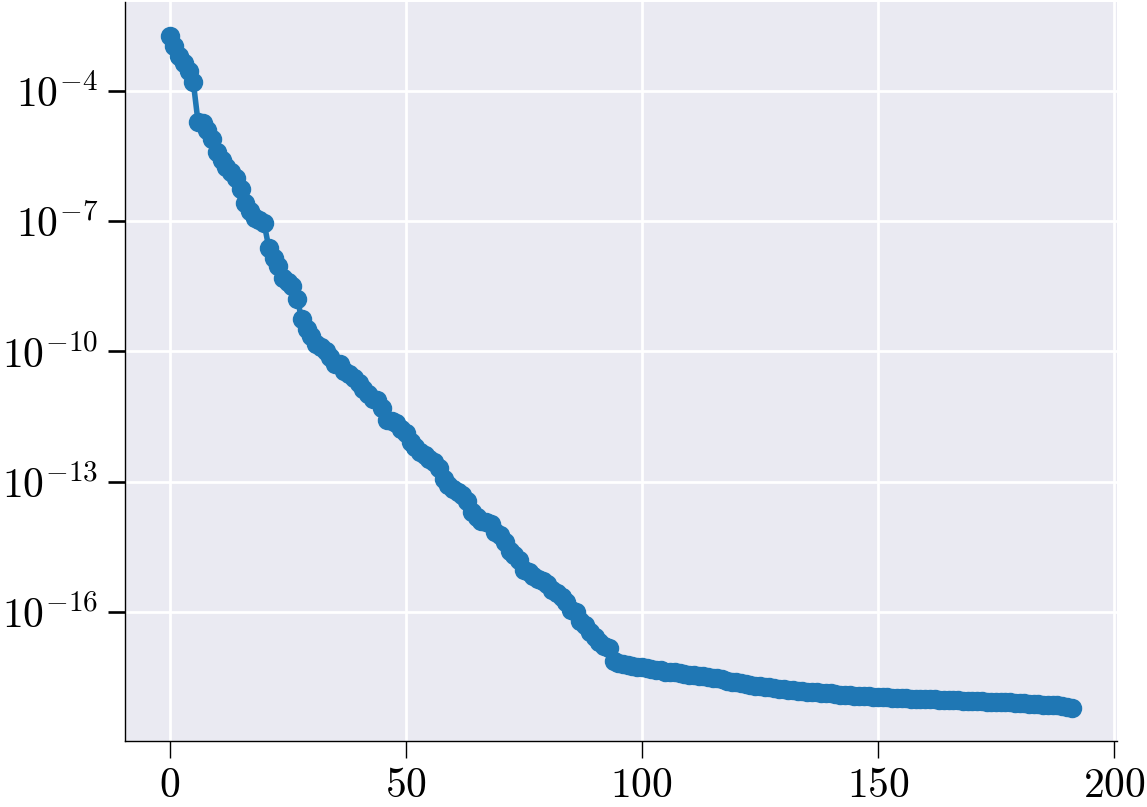

In [19]:
if _hyperreduce_ecsw:

    print("Performing SVD...")
    # Performs Singular Value Decomposition on q_mus matrix
    # Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
    Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

    # Plots singular values on a logarithmic y-scale to visualize their decay
    # This helps identify the effective rank/dimensionality of the matrix
    plt.semilogy(s, 'o-')

    # Takes the first 20 right singular vectors (rows of Vh)
    # This creates a reduced basis capturing the most significant modes
    V_q_eff = Vh[:100]

    # Computes a weighted combination of the basis vectors
    # Each basis vector is weighted equally (multiplied by 1)
    # This essentially sums all 20 basis vectors
    d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

    # Outputs the L2 norm of the resulting vector
    # This gives a sense of the magnitude of the combined basis representation
    print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [20]:
if _hyperreduce_ecsw:   
    # Solve the non-negative least squares (NNLS) problem using hyperreduce
    #   V_q_eff   : effective basis matrix
    #   verbosity : level of log output (2 = detailed)
    #   const_tol : tolerance for column selection
    #   zero_tol  : tolerance to treat values as zero
    #   plot      : disable plotting
    x_nnls_m, err = hyperreduce(
        V_q_eff,
        verbosity=2,
        const_tol=1e-8,
        zero_tol=1e-8,
        plot=False
    )

    # Compute and print the relative NNLS reconstruction error:
    #   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
    rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
    rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
    print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 100 1250 0 7.852832938741046e+00 3.177826403941786e+01
1 1 100 1250 1 7.801687267140805e+00 3.169597746429114e+01
2 2 100 1250 2 8.067919072107053e+00 3.162214640355771e+01
3 3 100 1250 3 8.087077065262445e+00 3.126015686257783e+01
4 4 100 1250 4 8.049455706620083e+00 2.993474528331879e+01
5 5 100 1250 5 8.127207461891746e+00 2.972035379939161e+01
6 6 100 1250 6 7.943212600341557e+00 2.952138616684839e+01
7 7 100 1250 7 7.621196724445145e+00 2.912602912059284e+01
8 8 100 1250 8 8.166647315286568e+00 2.886780306261091e+01
9 9 100 1250 9 7.892869394033521e+00 2.853945972428672e+01
10 10 100 1250 10 7.582527465457983e+00 2.839489470497556e+01
11 11 100 1250 11 7.462645044448745e+00 2.823666981778236e+01
12 12 100 1250 12 7.111053907248510e+00 2.501821834021762e+01
13 13 100 1250 13 7.231672415769588e+00 2.483603465831981e+01
14 14 100 1250 14 7.067956906335430e+00 2.450751328963887e+01
15 15 100 1250 15 7.446606326759055e+00

#### Plot Reduced Meshes with weights

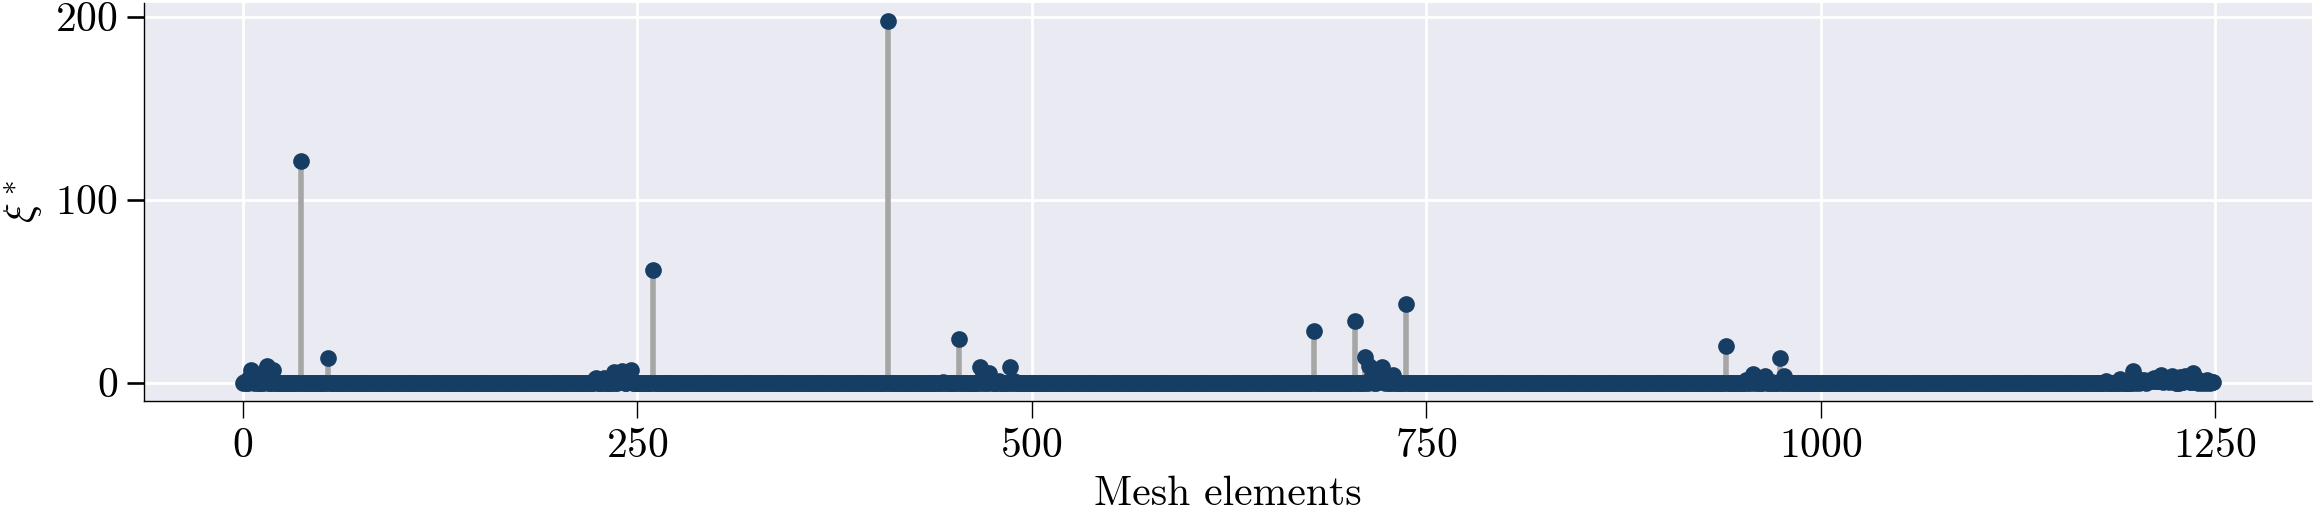

In [21]:
if visualize:
    fig, ax = plot_ecsw_weights(x_nnls_m)

    ## Mesh coloring based on selected elements

    hyper_basis = rom_data.basis
    mesh = hyper_basis.mesh

    w = np.asarray(x_nnls_m).ravel()
    sel_elems = np.flatnonzero(w > 1e-8)  # element indices on the mesh

    element_colors = np.zeros(mesh.nelements, dtype=float)
    element_colors[sel_elems] = 1.0

    mesh.save("colored_mesh.vtk", cell_data={"element_tags": [element_colors]})


### Run HyperROM simulation


In [22]:
if _hyperreduce_ecsw:
    # Run the hyper-reduced ROM simulation using the NNLS weights
    #   x_nnls_m : array of non-negative least squares coefficients,
    #              used here to weight the reduced basis contributions
    #rom will contain the hyper_rom solution as an attribute
    rom.run_hyper_rom_simulation_ecsw(x_nnls_m);
    #rom.run_hyper_rom_simulation(x_nnls_m)

Snap 1/32 params=[0.66680271 1.19531645]
1 0.14824650548442297
2 0.0002996349694546051
Snap 2/32 params=[0.89375125 1.81159795]
1 0.0046362683568081835
2 3.4421153261739746e-06
Snap 3/32 params=[0.86193867 1.34387451]
1 0.009546060250660944
2 1.372265830092756e-05
Snap 4/32 params=[0.57360027 1.64765219]
1 0.024221972529687507
2 0.00010056177834232191
Snap 5/32 params=[0.53645428 1.49369881]
1 0.0013887865735502775
2 2.483076809135947e-07
Snap 6/32 params=[0.77799067 1.51427722]
1 0.014743007897260189
2 2.8232181078461392e-05
Snap 7/32 params=[0.99729198 1.07976347]
1 0.0191854866769859
2 5.594193695743699e-05
Snap 8/32 params=[0.69216846 1.91283806]
1 0.03375099109002938
2 0.0002294765248880272
Snap 9/32 params=[0.7216945  1.25213704]
1 0.01864140091377735
2 4.522509732150115e-05
Snap 10/32 params=[0.96386031 1.73939024]
1 0.0014306100962520891
2 3.322971505967428e-07
Snap 11/32 params=[0.80803574 1.16608281]
1 0.007745700481718288
2 9.524417930191804e-06
Snap 12/32 params=[0.50250405

In [23]:
if rom_report:
    # Convert the list of nonlinear hyper-ROM solutions into a NumPy array
    NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

    # Retrieve the raw speed-up factors computed by the ROM
    hyper_ROM_speed_up = rom.hyper_speed_up

    # Drop the first element (often the full-order baseline) to analyze only relative speed-ups
    hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

    # Fetch the relative error of the hyper-reduced ROM from the ROM object
    hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 2.5439e-02
Relative L2 Error:        1.4598e-02
L∞ Error:                 6.2603e-03
Relative L∞ Error:        1.1747e-02
RMSE:                     1.9390e-03
MAE:                      1.4856e-03

Statistical Fit:
R² Score:                 0.9998
Explained Variance:       0.9888

Error Distribution:
Median Error:             -8.8389e-05
95th Percentile Error:    3.7885e-03

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 4.5584e-04
Max Rel L2 Error over time/parameter: 4.8726e-04
Min Rel L2 Error over time/parameter: 4.1192e-04
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

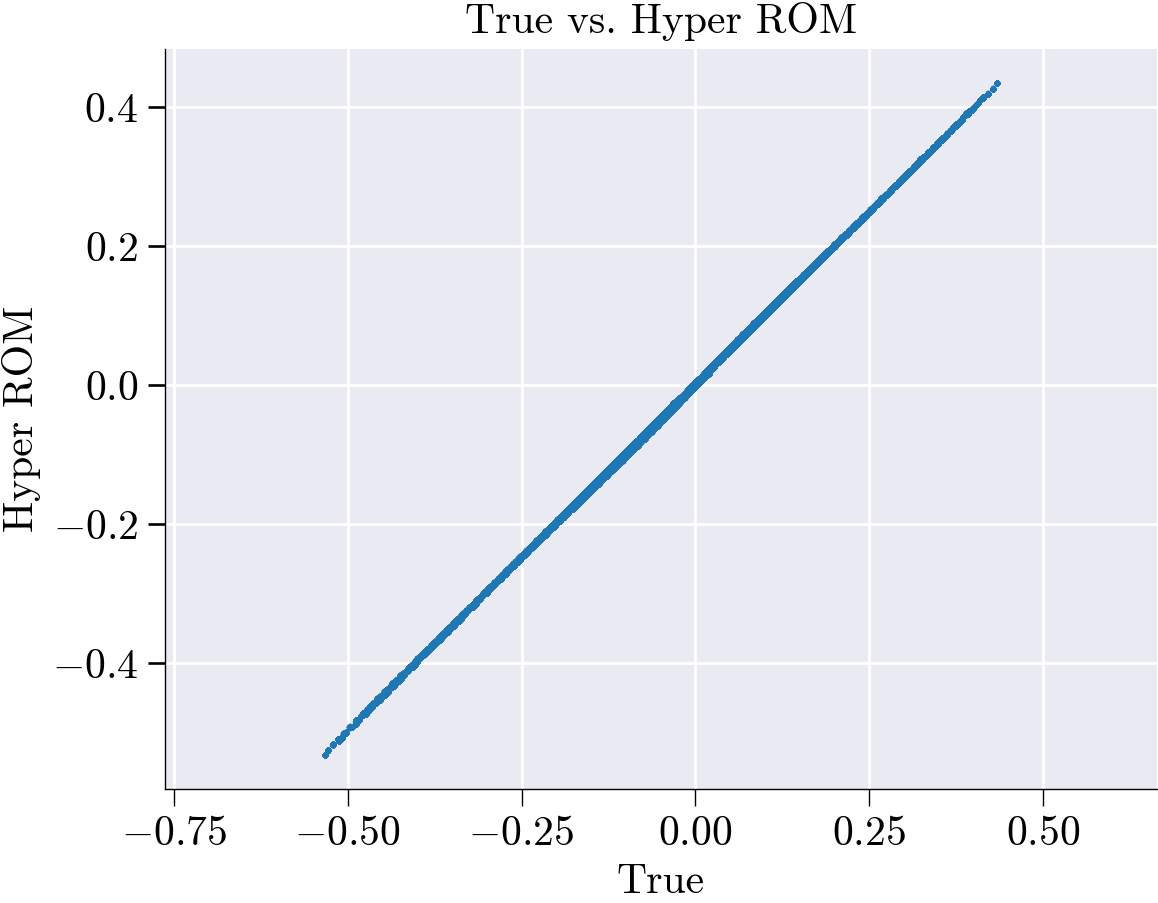

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


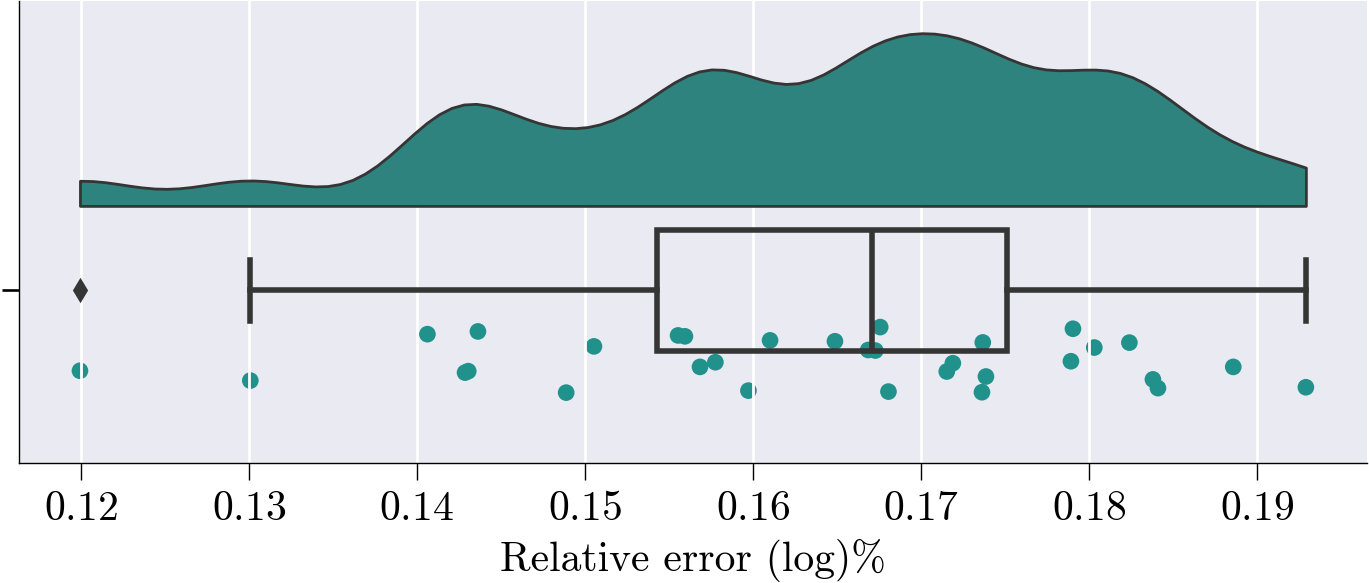

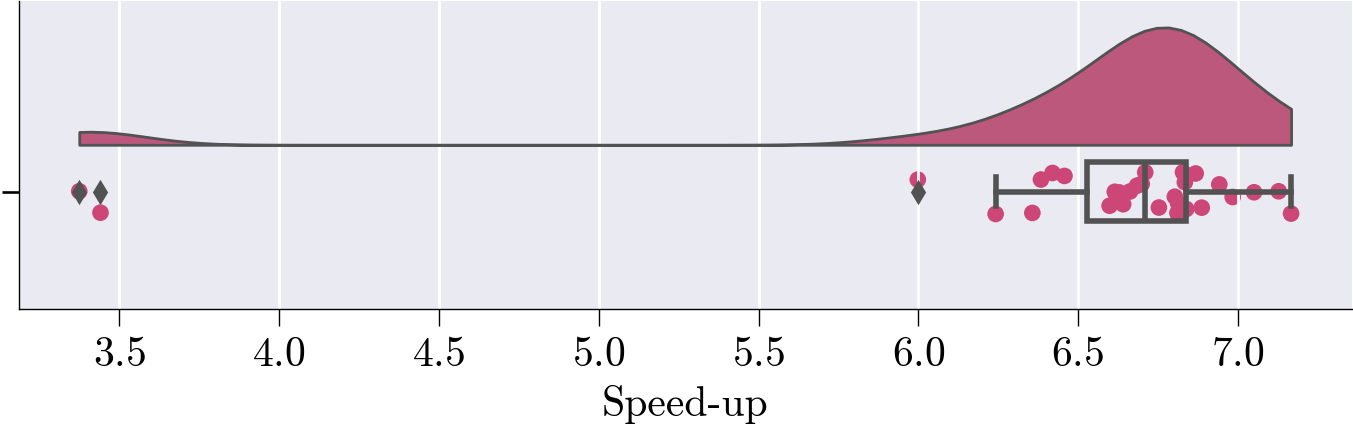

In [24]:
if rom_report:

    # --- Hyper-reduced ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        NLS_test,                   # full-order (true) solution snapshots
        NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
        hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
        hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'Hyper ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )